# 06 — Aggregate satisfaction estimation

**Spec: §10. The centerpiece.** This is what turns a classifier into an answer
to the client's actual question.

Measures TPR/FPR on the untouched holdout half, then runs the prevalence-shift
experiment that *demonstrates* the correction works rather than asserting it.

In [1]:
import sys, json, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
from src.normalize import normalize, NORMALIZE_VERSION
import joblib
from datasets import load_dataset
from src.predict import SatisfactionModel, load_config
from src.estimate import (confusion_rates, classify_and_count, acc_prevalence,
                          estimate_with_ci, resample_to_prevalence)

ds = load_dataset("tblard/allocine"); ds.pop("test")
raw_va = ds["validation"]["review"]
yva = np.array(ds["validation"]["label"])
hold_idx = np.load(REPO / "data" / "hold_idx.npy")

cfg = load_config(REPO / "inference_config.json", require_aggregation=False)
print("backend:", cfg.backend, "| T =", cfg.temperature,
      "| band =", (cfg.theta_lo, cfg.theta_hi))

C:\Users\Windownet\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


backend: sklearn | T = 0.6268 | band = (0.257, 0.7093)


## TPR / FPR on the holdout

Measured on the **confident** subset only, because that is the population the
estimator actually runs on: `estimate_satisfaction` excludes abstentions from
the base, so rates measured over all items would describe a different
population than the one being corrected.

In [2]:
model = SatisfactionModel(cfg)
Xh = [raw_va[i] for i in hold_idx]; yh = yva[hold_idx]

preds = model.predict(Xh, batch_size=512)
conf_mask = np.array([p.confident for p in preds])
y_pred = np.array([1 if p.label == "positif" else 0 for p in preds])

tpr, fpr = confusion_rates(yh[conf_mask], y_pred[conf_mask], positive=1)
print(f"holdout {len(Xh):,} | abstained {(~conf_mask).mean():.1%}")
print(f"TPR {tpr:.4f}   FPR {fpr:.4f}")
print(f"asymmetry |TPR-(1-FPR)| = {abs(tpr - (1 - fpr)):.4f} "
      f"<- the bias driver; zero would mean CC is unbiased")

holdout 10,000 | abstained 9.5%
TPR 0.9631   FPR 0.0426
asymmetry |TPR-(1-FPR)| = 0.0056 <- the bias driver; zero would mean CC is unbiased


In [3]:
cfg_path = REPO / "inference_config.json"
c = json.loads(cfg_path.read_text(encoding="utf-8"))
c.update(tpr=round(float(tpr), 4), fpr=round(float(fpr), 4))
cfg_path.write_text(json.dumps(c, indent=2, ensure_ascii=False) + "\n",
                    encoding="utf-8")
cfg = load_config(cfg_path)          # reload: config is now complete
model = SatisfactionModel(cfg)
print("config complete")

config complete


## The experiment that proves it works

Resample the holdout to a range of **known** true prevalences, then compare
what naive counting reports against the corrected estimate. Real predictions,
real rates — not a simulation.

In [4]:
levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
rows = []
for true_p in levels:
    idx = resample_to_prevalence(yh, true_p, n=4000, positive=1, seed=0)
    sub_pred, sub_conf = y_pred[idx], conf_mask[idx]
    cc = classify_and_count(sub_pred[sub_conf], positive=1)
    rows.append((true_p, cc, acc_prevalence(cc, tpr, fpr)))

print(f"{'true':>6} {'CC':>8} {'ACC':>8} {'CC err':>9} {'ACC err':>9}")
for t, cc, ac in rows:
    print(f"{t:>6.2f} {cc:>8.3f} {ac:>8.3f} {cc-t:>+9.3f} {ac-t:>+9.3f}")

cc_mae = float(np.mean([abs(cc - t) for t, cc, _ in rows]))
acc_mae = float(np.mean([abs(ac - t) for t, _, ac in rows]))
print(f"\nMAE   CC {cc_mae:.4f}   ACC {acc_mae:.4f}   "
      f"-> {cc_mae / max(acc_mae, 1e-9):.1f}x better")

  true       CC      ACC    CC err   ACC err
  0.10    0.140    0.106    +0.040    +0.006
  0.20    0.232    0.206    +0.032    +0.006
  0.30    0.327    0.309    +0.027    +0.009
  0.40    0.417    0.406    +0.017    +0.006
  0.50    0.509    0.506    +0.009    +0.006
  0.60    0.599    0.604    -0.001    +0.004
  0.70    0.692    0.705    -0.008    +0.005
  0.80    0.784    0.805    -0.016    +0.005
  0.90    0.874    0.904    -0.026    +0.004

MAE   CC 0.0195   ACC 0.0058   -> 3.3x better


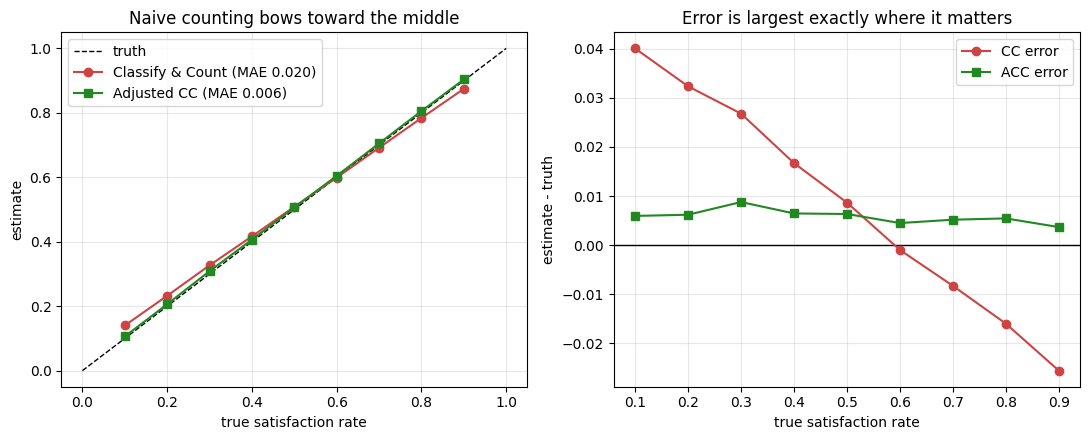

In [5]:
t_, cc_, ac_ = zip(*rows)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="truth")
axes[0].plot(t_, cc_, "o-", color="#c44", label=f"Classify & Count (MAE {cc_mae:.3f})")
axes[0].plot(t_, ac_, "s-", color="#282", label=f"Adjusted CC (MAE {acc_mae:.3f})")
axes[0].set_xlabel("true satisfaction rate"); axes[0].set_ylabel("estimate")
axes[0].set_title("Naive counting bows toward the middle")
axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].axhline(0, color="k", lw=1)
axes[1].plot(t_, [c - t for t, c, _ in rows], "o-", color="#c44", label="CC error")
axes[1].plot(t_, [a - t for t, _, a in rows], "s-", color="#282", label="ACC error")
axes[1].set_xlabel("true satisfaction rate"); axes[1].set_ylabel("estimate - truth")
axes[1].set_title("Error is largest exactly where it matters")
axes[1].legend(); axes[1].grid(alpha=.3)

plt.tight_layout(); plt.savefig(REPO / "data" / "fig_cc_vs_acc.png", dpi=120)
plt.show()

## Confidence intervals, both uncertainty sources

`estimate_with_ci` resamples the comment batch **and** the labelled holdout,
because the correction divides by `(TPR - FPR)` and error there is amplified.
Reporting only comment-sampling noise understates the interval.

In [6]:
for true_p in (0.3, 0.5, 0.8):
    idx = resample_to_prevalence(yh, true_p, n=2000, positive=1, seed=1)
    est = estimate_with_ci(y_pred[idx][conf_mask[idx]],
                           yh[conf_mask], y_pred[conf_mask],
                           positive=1, n_boot=1500, seed=0)
    hit = "OK " if est.ci_low <= true_p <= est.ci_high else "MISS"
    print(f"true {true_p:.0%} -> {est.rate:.1%} "
          f"[{est.ci_low:.1%}, {est.ci_high:.1%}]  {hit}   "
          f"(naive would say {est.naive_rate:.1%})")

true 30% -> 30.5% [28.0%, 32.9%]  OK    (naive would say 32.3%)


true 50% -> 50.4% [48.0%, 52.9%]  OK    (naive would say 50.7%)


true 80% -> 80.2% [78.1%, 82.4%]  OK    (naive would say 78.1%)


In [7]:
json.dump({"tpr": round(float(tpr), 4), "fpr": round(float(fpr), 4),
           "abstain_rate": round(float((~conf_mask).mean()), 4),
           "cc_mae": round(cc_mae, 4), "acc_mae": round(acc_mae, 4),
           "improvement_x": round(cc_mae / max(acc_mae, 1e-9), 1),
           "sweep": [{"true": t, "cc": round(c, 4), "acc": round(a, 4)}
                     for t, c, a in rows]},
          open(REPO / "data" / "results_aggregate.json", "w"), indent=2)
print("saved results_aggregate.json")

saved results_aggregate.json
